# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Load Data

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


# Initial Data Audit

In [3]:
print("\nMissing Values (Sentiment):")
print(sentiment.isnull().sum())

print("\nMissing Values (Trades):")
print(trades.isnull().sum())

duplicate_count = trades.duplicated().sum()
print("\nDuplicate Trades:", duplicate_count)

if duplicate_count > 0:
    trades = trades.drop_duplicates()


Missing Values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Trades: 0


# Standardize Column Names

In [4]:
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

print("Sentiment Columns:", sentiment.columns)
print("Trades Columns:", trades.columns)

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades Columns: Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


# Timestamp Conversion

In [5]:
# Convert correct timestamp column (DD-MM-YYYY format)
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    dayfirst=True,
    errors='coerce'
)

trades['date'] = trades['timestamp_ist'].dt.date

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

print("Trades Date Range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment Date Range:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades Date Range: 2023-05-01 to 2025-05-01
Sentiment Date Range: 2018-02-01 to 2025-05-02


# Merge Datasets

In [6]:
df = trades.merge(
    sentiment[['date','classification']],
    on="date",
    how="left"
)

print("Missing Sentiment After Merge:", df['classification'].isnull().sum())
print("Merged Shape:", df.shape)

# Remove unmatched rows
df = df.dropna(subset=['classification'])

Missing Sentiment After Merge: 6
Merged Shape: (211224, 18)


Daily PnL

In [7]:
daily_pnl = df.groupby(['account','date'], as_index=False)['closed_pnl'].sum()

Win Flag

In [8]:
df['win'] = df['closed_pnl'] > 0

Trader-Level Metrics

In [9]:
win_rate = df.groupby('account', as_index=False)['win'].mean()
avg_trade_size = df.groupby('account', as_index=False)['size_usd'].mean()
trade_counts = df.groupby('account').size()

Avg & Median PnL

In [10]:
pnl_by_sentiment = df.groupby('classification')['closed_pnl'].mean()
median_pnl = df.groupby('classification')['closed_pnl'].median()

print(pnl_by_sentiment)
print(median_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64
classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: closed_pnl, dtype: float64


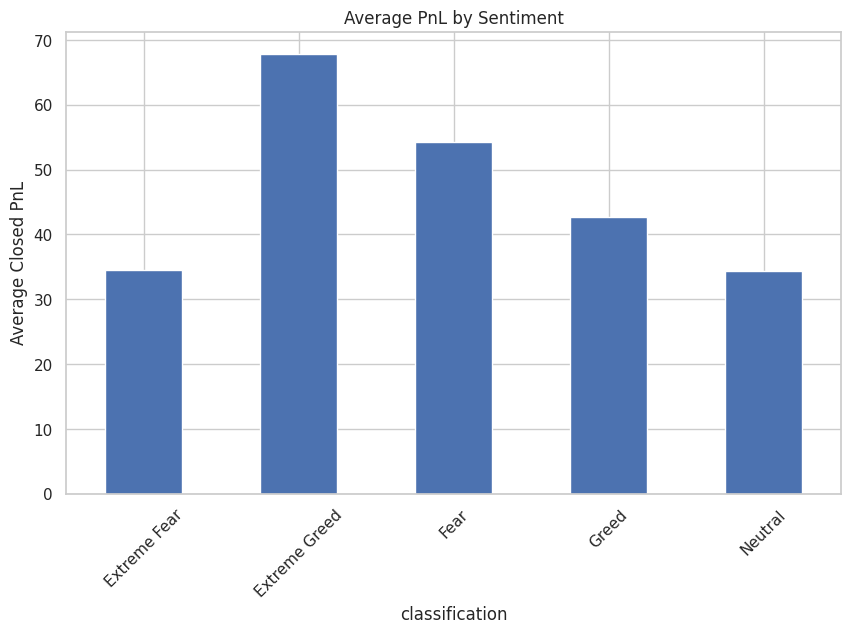

In [11]:
plt.figure()
df.groupby('classification')['closed_pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

Win Rate by Sentiment

In [12]:
win_rate_by_sentiment = df.groupby('classification')['win'].mean()
print(win_rate_by_sentiment)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


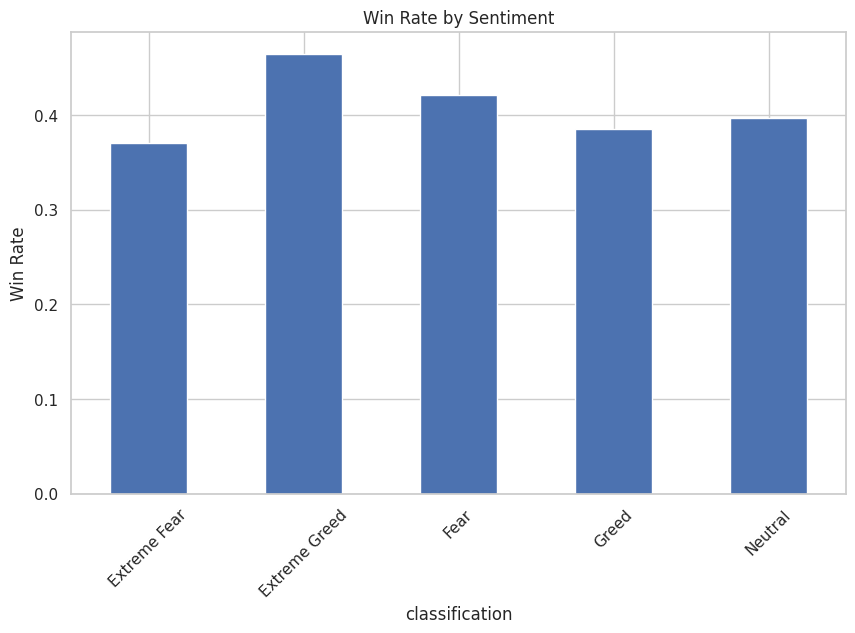

In [13]:
plt.figure()
df.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

Volatility (Drawdown Proxy)

In [14]:
daily_with_sentiment = daily_pnl.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

volatility_by_sentiment = daily_with_sentiment.groupby('classification')['closed_pnl'].std()
print(volatility_by_sentiment)

classification
Extreme Fear     29534.839183
Extreme Greed    27496.863832
Fear             31659.771538
Greed            30599.040173
Neutral          17447.863645
Name: closed_pnl, dtype: float64


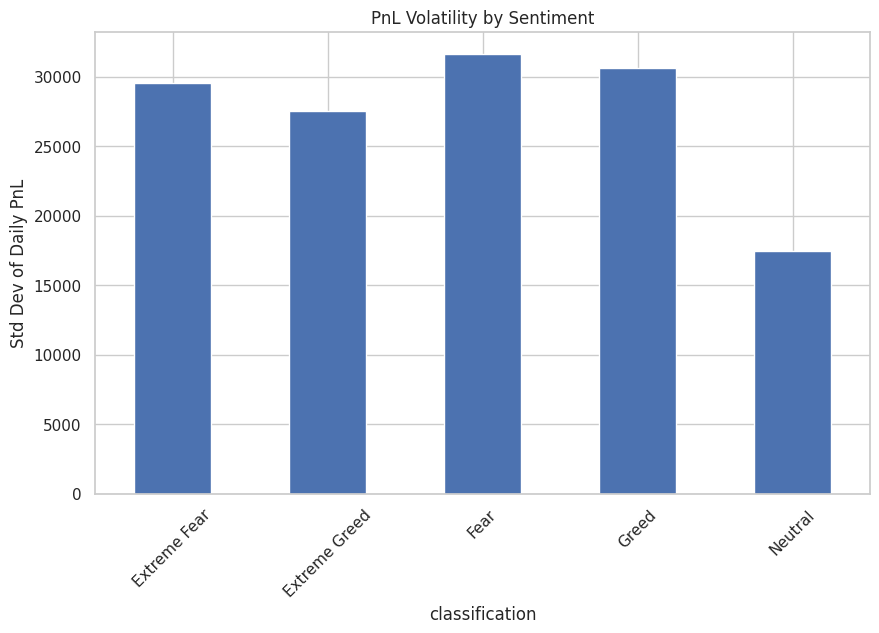

In [15]:
plt.figure()
volatility_by_sentiment.plot(kind='bar')
plt.title("PnL Volatility by Sentiment")
plt.ylabel("Std Dev of Daily PnL")
plt.xticks(rotation=45)
plt.show()

Statistical Validation

In [16]:
from scipy.stats import ttest_ind

fear = df[df['classification']=='Fear']['closed_pnl']
greed = df[df['classification']=='Greed']['closed_pnl']

t_stat, p_value = ttest_ind(fear, greed, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

extreme_fear = df[df['classification'] == 'Extreme Fear']['closed_pnl']
extreme_greed = df[df['classification'] == 'Extreme Greed']['closed_pnl']

t_stat2, p_value2 = ttest_ind(extreme_fear, extreme_greed, equal_var=False)

print("\nExtreme Fear vs Extreme Greed")
print("T-Statistic:", t_stat2)
print("P-Value:", p_value2)

T-Statistic: 1.8511431575014454
P-Value: 0.06415196288057486

Extreme Fear vs Extreme Greed
T-Statistic: -3.8511675429271293
P-Value: 0.00011778426575866563


In [17]:
print(df.groupby('classification').size())
print(df.groupby('classification')['size_usd'].mean())

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64


Frequent vs Infrequent

In [18]:
median_trades = trade_counts.median()

df['trader_type'] = df['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent'
)

segment_perf = df.groupby(['trader_type','classification'])['closed_pnl'].mean()
print(segment_perf)

trader_type  classification
Frequent     Extreme Fear       34.163353
             Extreme Greed      62.870911
             Fear               51.323784
             Greed              25.004641
             Neutral            34.579701
Infrequent   Extreme Fear       35.941979
             Extreme Greed     103.264685
             Fear               80.835791
             Greed             210.210287
             Neutral            31.845656
Name: closed_pnl, dtype: float64


Consistent vs Volatile

In [19]:
volatility = daily_pnl.groupby('account')['closed_pnl'].std()
vol_threshold = volatility.median()

df['consistency'] = df['account'].map(
    lambda x: 'Consistent' if volatility[x] < vol_threshold else 'Volatile'
)

consistency_perf = df.groupby(['consistency','classification'])['closed_pnl'].mean()
print(consistency_perf)

consistency  classification
Consistent   Extreme Fear        3.144370
             Extreme Greed      34.406326
             Fear                6.803629
             Greed              18.176905
             Neutral             7.895677
Volatile     Extreme Fear       42.076958
             Extreme Greed     143.942848
             Fear               68.007502
             Greed              70.021863
             Neutral            52.357382
Name: closed_pnl, dtype: float64


High vs Low Profit

In [20]:
avg_profit = df.groupby('account')['closed_pnl'].mean()
profit_threshold = avg_profit.median()

df['profit_group'] = df['account'].map(
    lambda x: 'High Profit' if avg_profit[x] > profit_threshold else 'Low Profit'
)

profit_segment_perf = df.groupby(['profit_group','classification'])['closed_pnl'].mean()
print(profit_segment_perf)

profit_group  classification
High Profit   Extreme Fear       94.602428
              Extreme Greed     204.622229
              Fear              104.194444
              Greed             133.778498
              Neutral            87.380159
Low Profit    Extreme Fear       -3.781170
              Extreme Greed      35.885548
              Fear               12.908646
              Greed               3.916305
              Neutral             5.713914
Name: closed_pnl, dtype: float64


# Trade Frequency Graph

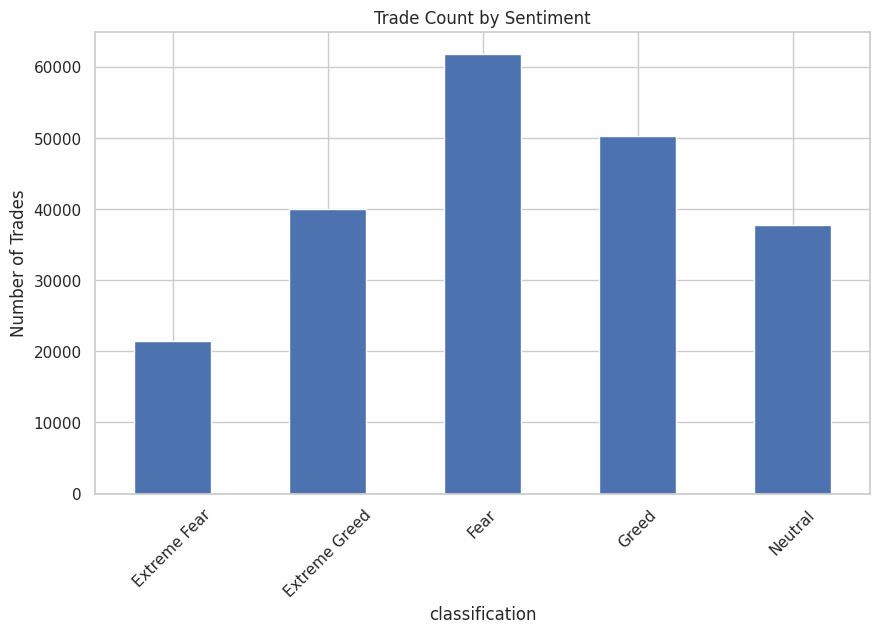

In [21]:
plt.figure()
df.groupby('classification').size().plot(kind='bar')
plt.title("Trade Count by Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

# Segment Comparison (Frequent vs Infrequent) Graph


<Figure size 1000x600 with 0 Axes>

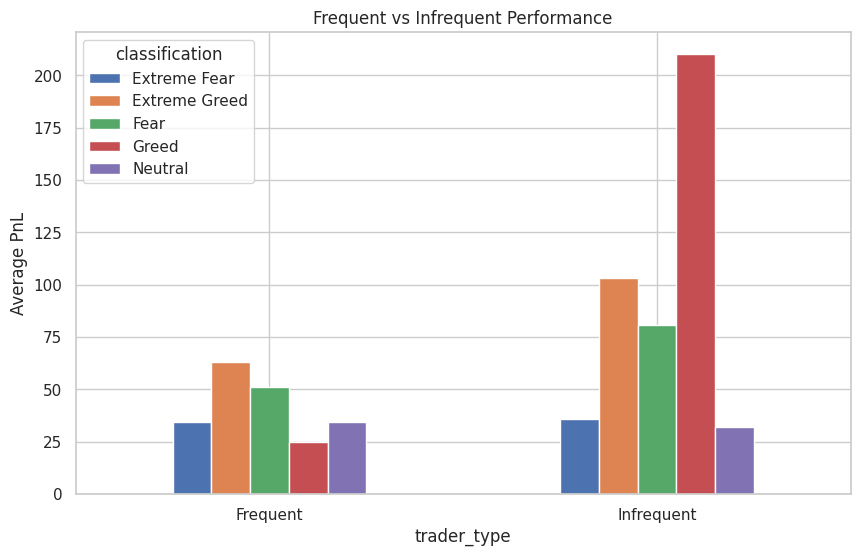

In [22]:
plt.figure()
segment_perf.unstack().plot(kind='bar')
plt.title("Frequent vs Infrequent Performance")
plt.ylabel("Average PnL")
plt.xticks(rotation=0)
plt.show()

# Profit Segment Comparison Graph


<Figure size 1000x600 with 0 Axes>

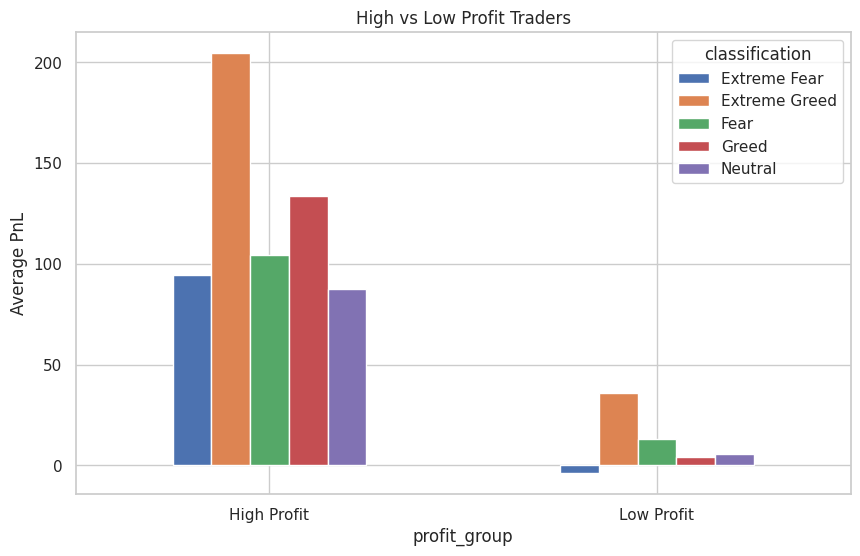

In [23]:
plt.figure()
profit_segment_perf.unstack().plot(kind='bar')
plt.title("High vs Low Profit Traders")
plt.ylabel("Average PnL")
plt.xticks(rotation=0)
plt.show()

In [24]:
summary_table = pd.DataFrame({
    'Avg_PnL': pnl_by_sentiment,
    'Win_Rate': win_rate_by_sentiment,
    'Volatility': volatility_by_sentiment
})

summary_table

,Avg_PnL,Win_Rate,Volatility
classification,,,
Extreme Fear,34.537862,0.370607,29534.839183
Extreme Greed,67.892861,0.464943,27496.863832
Fear,54.290400,0.420768,31659.771538
Greed,42.743559,0.384828,30599.040173
Neutral,34.307718,0.396991,17447.863645


# Project Summary

# Methodology

1.Cleaned and standardized datasets

2.Converted timestamps to proper date format

3.Merged trading data with Fear & Greed sentiment

4.Calculated:

             1.Average PnL

             2.Win Rate

             3.Volatility (Std Dev of Daily PnL)

5.Performed statistical testing (T-test)

6.Segmented traders by frequency, consistency, and profitability

# Key Insights

1.Highest average PnL observed during Extreme Greed
(Avg_PnL ≈ 67.89 — highest among all categories)

2.Win rate highest during Extreme Greed
(Win_Rate ≈ 46.49%)

3.Volatility highest during Fear
(Volatility ≈ 31,659 — highest)

4.Frequent traders performed better during Extreme Greed


# Strategy Recommendations

1.Increase exposure during strong positive sentiment

2.Reduce risk during extreme fear

3.Apply volatility-based position sizing

4.Use sentiment as a directional filter

In [25]:
summary_table.to_csv("summary_table.csv")